Basic

In [108]:
import numpy as np
import os

Visualization

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

Image Handling

In [110]:
from PIL import Image

Machine Learning Tools

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Setting Random Seed

In [112]:
np.random.seed(42)

Defining Dataset Paths

In [113]:
base_path = "../Data"

train_path = os.path.join(base_path, "Training")
test_path = os.path.join(base_path, "Testing")

if not os.path.exists(train_path):
    print("Training path not found!")

if not os.path.exists(test_path):
    print("Testing path not found!")

Listing Categories

In [114]:
categories = os.listdir(train_path)
categories = sorted(os.listdir(train_path))
print(categories)

['glioma', 'meningioma', 'notumor', 'pituitary']


Visualizing Number of Images per Category

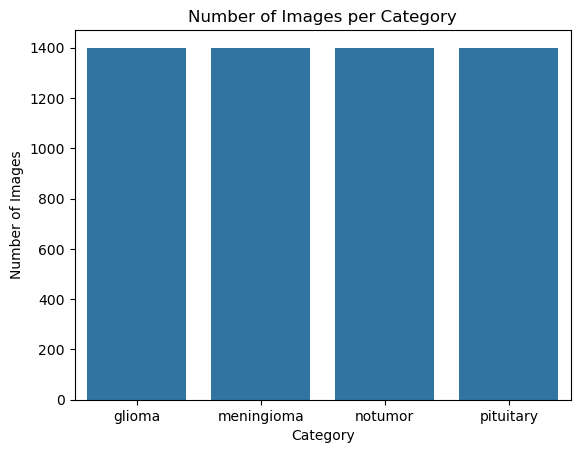

In [115]:
counts = []

for category in categories:
    path = os.path.join(train_path, category)
    counts.append(len(os.listdir(path)))

sns.barplot(x=categories, y=counts)
plt.title("Number of Images per Category")
plt.xlabel("Category")
plt.ylabel("Number of Images")

plt.show()

Image Dimensions Distribution

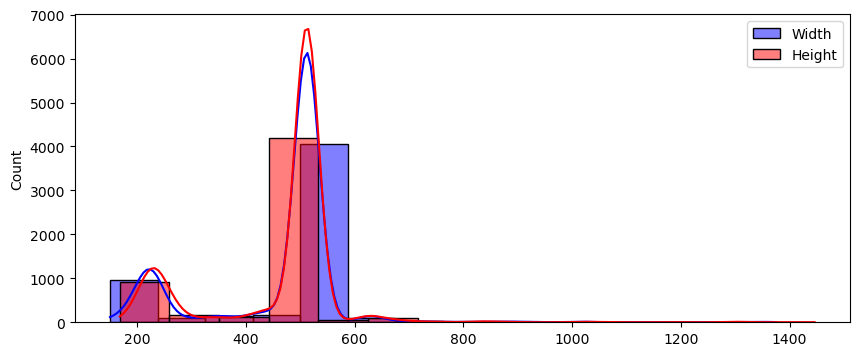

In [116]:
widths, heights = [], []
for category in categories:
    path = os.path.join(train_path, category)
    for file in os.listdir(path):
        img = Image.open(os.path.join(path, file))
        widths.append(img.width)
        heights.append(img.height)

plt.figure(figsize=(10,4))
sns.histplot(widths, kde=True, color='blue', label='Width')
sns.histplot(heights, kde=True, color='red', label='Height')
plt.legend()
plt.show()

Function to Load and Preprocess Images

In [117]:
def load_images_from_folder(folder, label, image_size=(64,64), flatten=True):
    images = []
    labels = []

    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        if os.path.isfile(filepath):
            try:
                img = Image.open(filepath).convert('L')
                img = img.resize(image_size)
                img_array = np.array(img)

                if flatten:
                    img_array = img_array.flatten()

                images.append(img_array)
                labels.append(label)

            except:
                print(f"Error loading {filename}")

    return images, labels

Mapping Labels and Loading All Images

In [118]:
label_map = {category: idx for idx, category in enumerate(categories)}
print(label_map)

all_images = []
all_labels = []

for category in categories:
    path = os.path.join(train_path, category)
    label = label_map[category]

    images, labels = load_images_from_folder(path, label)
    
    all_images.extend(images)
    all_labels.extend(labels)

x = np.array(all_images)
y = np.array(all_labels)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Splitting Data into Training and Testing Sets

In [119]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Scaling the Features

In [120]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Training Logistic Regression Model

In [121]:
model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(x_train,y_train)

c:\Users\Hend\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

Predicting on Test Data

In [122]:
y_pred = model.predict(x_test)

Evaluating the Model

In [123]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8392857142857143


Confusion Matrix Visualization

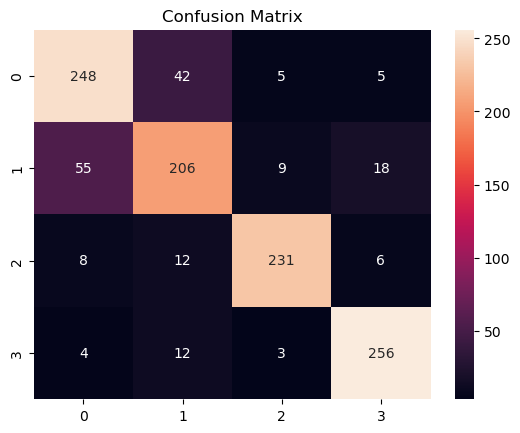

In [124]:
cm = confusion_matrix(y_test, y_p)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [125]:
print(classification_report(y_test, y_p))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       300
           1       0.76      0.72      0.74       288
           2       0.93      0.90      0.91       257
           3       0.90      0.93      0.91       275

    accuracy                           0.84      1120
   macro avg       0.84      0.84      0.84      1120
weighted avg       0.84      0.84      0.84      1120



In [130]:
def predict_image(image_path, model, image_size=(64,64)):
    
    img = Image.open(image_path).convert('L')
    img = img.resize(image_size)
    img_array = np.array(img).flatten()  
    img_array = img_array.reshape(1, -1)  
    
    
    pred = model.predict(img_array)
    
    return pred[0]  


image_path = r"C:\Users\Hend\Downloads\Brain Tumor\Data\Testing\pituitary\Te-pi_1.jpg"
predicted_label = predict_image(image_path, model)
label_names = {0:'glioma', 1:'meningioma', 2:'notumor', 3:'pituitary'}
print("Predicted Class:", label_names[predicted_label])

Predicted Class: pituitary
